In [6]:
import shap
import os
import joblib
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, '..'))
prefix = '../'

# On ajoute la racine du projet au PATH de Python pour qu'il trouve 'config.py'
if project_root not in sys.path:
    sys.path.append(project_root)
# ---------------------------------------------

from config import params
from utils.Functions import split_dataset

# 1. Charger les données brutes (avec le bon préfixe)
df = pd.read_csv(prefix + params['data_dir'] + params['data_name'])

# 2. Charger le modèle entraîné (Changez 'sgd' par 'logistic' ou 'mlp')
model_name = 'mlp'
model_path = f'{prefix}model_output/{model_name}/{model_name}.pkl'
model = joblib.load(model_path)

# 3. Préparer les données
y = df[params['colonne_cible']].sample(5000, random_state=42)
X = df.drop(columns=[params['colonne_cible']]).sample(5000, random_state=42)
X_train, X_test, y_train, y_test = split_dataset(X, y)
X, y = model.prepare(X_train, y_train)
print(f"Modèle {model_name} et données chargés avec succès !")
print(f"Taille du jeu de test : {X_test.shape[0]} lignes")

Modèle mlp et données chargés avec succès !
Taille du jeu de test : 1000 lignes


PermutationExplainer explainer: 1001it [01:34,  9.43it/s]                         
C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_20292\1175238582.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)
h:\Documents\GIA3\IA_app\rain_prediction\.venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
h:\Documents\GIA3\IA_app\rain_prediction\.venv\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the g

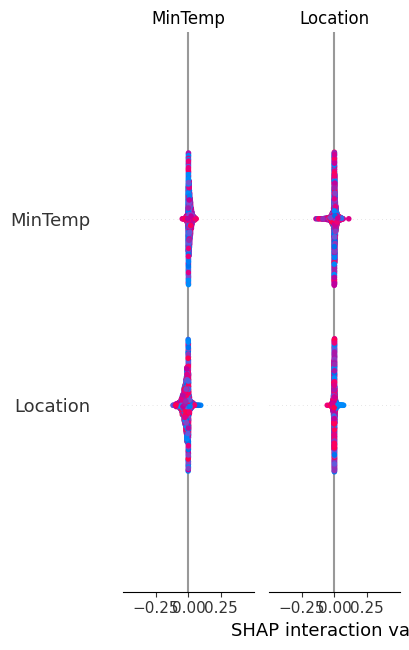

In [ ]:
from PIL.ImageShow import show
explainer = shap.Explainer(model.predict_proba, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, show=False, plot_type="bar")

plt.tight_layout()
plt.show()
